# Telco Customer Churn - Predictive Modeling in Python

This notebook demonstrates the predictive modeling phase of the Telco Customer Churn project. It includes one-hot encoding, train-test splitting, random forest classification, model evaluation, and feature importance visualization.


## 6.1 One-Hot Encoding and Preprocessing

In [49]:
import pandas as pd

# Load the cleaned dataset
df = pd.read_csv("Babar_Telco_Cleaned.csv")

# Convert target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# One-hot encode categorical variables
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


## 6.2 Train-Test Split

In [50]:
from sklearn.model_selection import train_test_split

X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1695,0,54,70.70,3770.00,True,True,True,True,False,True,...,False,True,False,False,True,False,True,False,True,False
1095,0,1,80.55,80.55,True,False,False,True,False,False,...,False,True,False,False,False,False,True,False,True,False
3889,0,13,19.30,259.65,True,False,False,True,False,False,...,True,False,True,False,True,False,False,True,False,False
3667,1,24,96.55,2263.45,False,True,True,True,False,False,...,False,True,False,True,False,True,True,False,True,False
2902,1,6,74.10,450.90,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


## 6.3 Model Selection and Training

In [51]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

## 6.4 Model Evaluation

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1407  132]
 [ 305  269]]
              precision    recall  f1-score   support

           0       0.82      0.91      0.87      1539
           1       0.67      0.47      0.55       574

    accuracy                           0.79      2113
   macro avg       0.75      0.69      0.71      2113
weighted avg       0.78      0.79      0.78      2113



## 6.5 Feature Importance

/var/folders/24/2l0f9b5d1j71s1c0q413ddj40000gn/T/ipykernel_93150/3375548799.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, hue=None, palette="viridis")


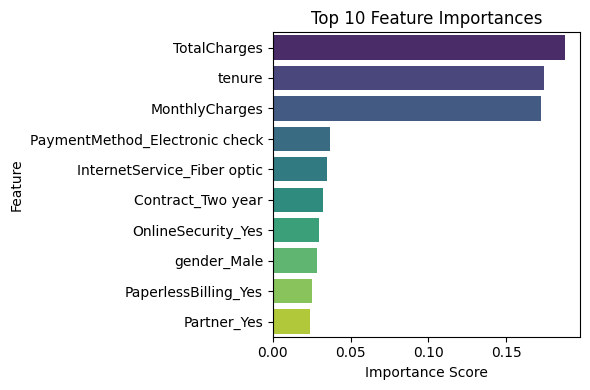

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importances = pd.Series(model.feature_importances_, index=X.columns)
top_features = feature_importances.sort_values(ascending=False).head(10)

plt.figure(figsize=(6,4))
sns.barplot(x=top_features.values, y=top_features.index, hue=None, palette="viridis")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 6.6 Retrain Random Forest on Top 10 Features for Streamlit

In [55]:
# Define top 10 features manually (based on feature importance)
top_10_features = [
    'tenure',
    'TotalCharges',
    'MonthlyCharges',
    'InternetService_Fiber optic',
    'Contract_Two year',
    'PaymentMethod_Electronic check',
    'OnlineSecurity_Yes',
    'Contract_One year',
    'TechSupport_Yes',
    'PaperlessBilling_Yes'
]

In [56]:
# Prepare data using only top 10 features
X = df_encoded[top_10_features]
y = df_encoded['Churn']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [57]:
# Train new Random Forest model
from sklearn.ensemble import RandomForestClassifier

best_rf_model_top10 = RandomForestClassifier(n_estimators=100, max_depth=10, max_features='sqrt', random_state=42)
best_rf_model_top10.fit(X_train, y_train)

RandomForestClassifier(max_depth=10, random_state=42)

In [58]:
# Save the new top-10 feature model
import joblib

joblib.dump(best_rf_model_top10, "rf_churn_model_top10.pkl")
print("✅ Model saved as rf_churn_model_top10.pkl")

✅ Model saved as rf_churn_model_top10.pkl
